In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense 
from tensorflow.keras.optimizers import Adam


In [8]:
df=pd.read_csv('/content/drive/MyDrive/datasets/car_price.csv', encoding= 'ISO-8859-1')
df

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,USA,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1,57,59729.15130,5358.712177,560304.0671,55915.46248
...,...,...,...,...,...,...,...,...,...
495,Walter,ligula@Cumsociis.ca,USA,0,41,71942.40291,6995.902524,541670.1016,48901.44342
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,USA,1,38,56039.49793,12301.456790,360419.0988,31491.41457
497,Pearl,penatibus.et@massanonante.com,USA,1,54,68888.77805,10611.606860,764531.3203,64147.28888
498,Nell,Quisque.varius@arcuVivamussit.net,USA,1,59,49811.99062,14013.034510,337826.6382,45442.15353


In [9]:
df.drop(columns=['Customer Name','Customer e-mail', 'Country'], inplace=True)

## Define Features X and Target 

## Data Scaling

In [10]:
x= df.iloc[:, :-1]
y= df.iloc[:,-1]

In [11]:
scaler=StandardScaler()
x=scaler.fit_transform(x)

## Data Splitting 

In [12]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)

## ANN Model 

In [13]:
x_train.shape

(400, 5)

In [14]:
model=Sequential([
    Dense(128,  activation='relu', input_dim=5),
          
    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(1,activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')  ## no need for metric because  we are using mean squared error

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
history= model.fit(x_train, y_train, epochs=200, batch_size=8, verbose=1,  validation_split=0.2)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2076158336.0000 - val_loss: 1938591360.0000
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2075573632.0000 - val_loss: 1937231488.0000
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2071396736.0000 - val_loss: 1929193856.0000
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2052975616.0000 - val_loss: 1900541568.0000
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2001399168.0000 - val_loss: 1828484352.0000
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1886398848.0000 - val_loss: 1688090496.0000
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1673853568.0000 - val_loss: 1448956416.0000
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1347902720.0000 - val_loss: 1109040768.0000
Epoch 9/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 932030464.0000 - val_loss: 721545024.0000
Epoch 10/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 519355968.0000 

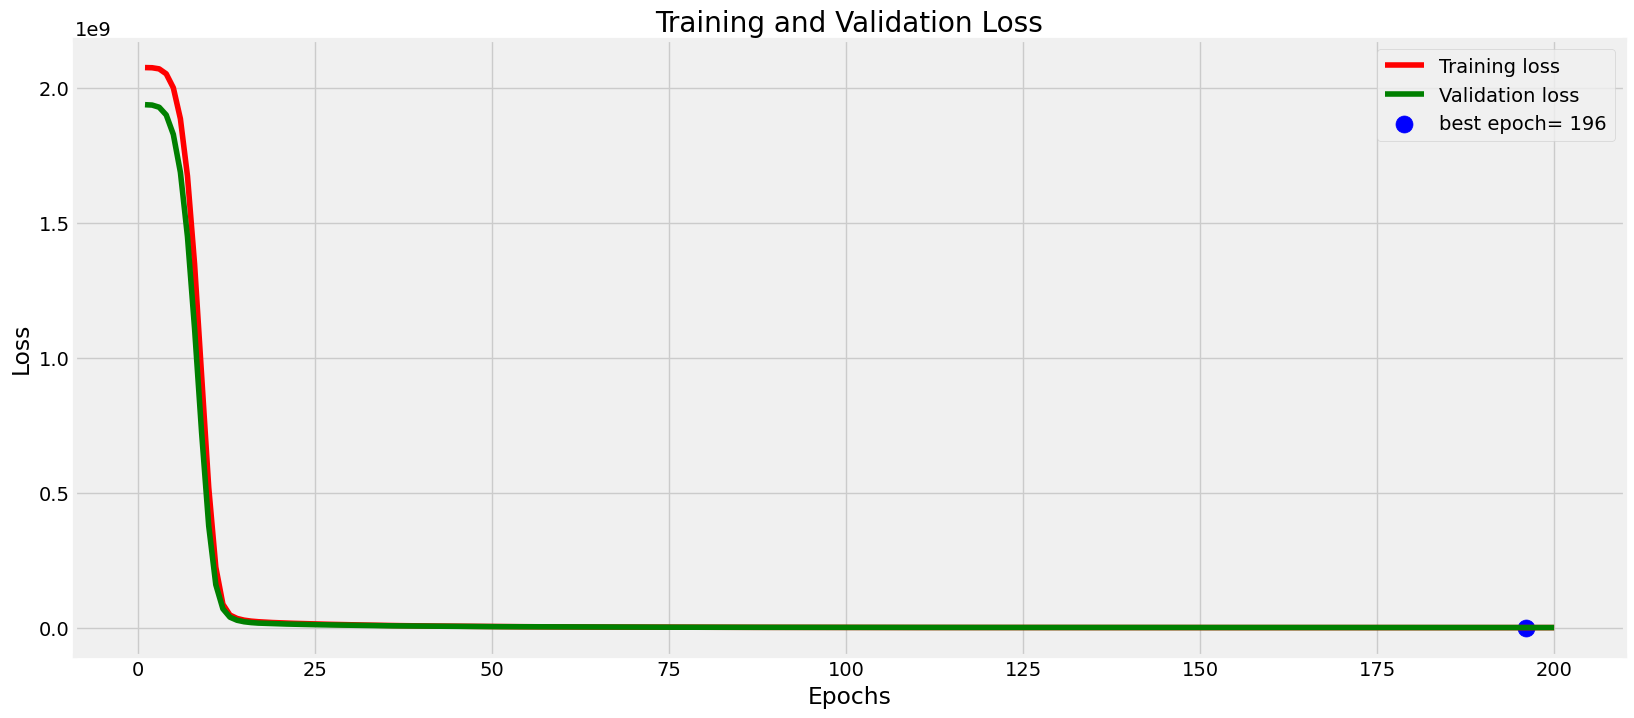

In [16]:
# Define needed variables
tr_loss = history.history['loss']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

Epochs = [i+1 for i in range(len(tr_loss))]
loss_label = f'best epoch= {str(index_loss + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout
plt.show()

In [17]:
y_pred=model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [18]:
from sklearn.metrics import r2_score
R2=r2_score(y_test, y_pred)
print(f'Accuracy Score Using R2 Score is: {R2}')

Accuracy Score Using R2 Score is: 0.9991667470110155


In [19]:
pd.DataFrame(y_test)

,Car Purchase Amount
361,46082.80993
73,45058.89690
374,63079.84329
155,31837.22537
104,60461.24268
...,...
347,49079.29461
86,45167.32542
75,50958.08115
438,43898.27330


In [20]:
y_pred=list(y_pred)

In [21]:
pd.DataFrame({'Predicted Price': y_pred})

,Predicted Price
0,[45951.32]
1,[45057.887]
2,[62870.914]
3,[31774.164]
4,[60098.85]
...,...
95,[49035.32]
96,[44515.77]
97,[50936.8]
98,[43512.086]
